<a href="https://colab.research.google.com/github/7REVOLUTiOn/Computer-Vision-/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%AD%D1%84%D1%84%D0%B5%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F_%D0%BE%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D1%80%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B2%D1%8B%D1%85_%D0%B8_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BD%D1%8B%D1%85_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B2_XARRAY_%D0%B8_RIOXARRAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Эффективная обработка растровых и векторных данных в XARRAY и RIOXARRAY**

## **Раздел 1. Эффективная работа с наборами векторных данных в библиотеке XARRAY**

In [ ]:
%%capture
!pip install xarray pooch cftime

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Настройка сохранения атрибутов и отображения данных
xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)

---

### **Задание 1. Изучение нового набора данных**

1. Загрузите обучающий набор данных Xarray `rasm`.


- Xarray предоставляет встроенный доступ к нескольким [обучающим наборам данных](https://docs.xarray.dev/en/latest/generated/xarray.tutorial.open_dataset.html), которые мы можем загрузить с помощью `xr.tutorial.open_dataset`.

In [ ]:
ds = xr.tutorial.open_dataset("rasm")

2. Изучите объект `Dataset` и перечислите все переменные и измерения.


In [ ]:
print("Переменные:", list(ds.data_vars))
print("Измерения:", dict(ds.dims))

Переменные: ['Tair']
Измерения: {'time': 36, 'y': 205, 'x': 275}


/tmp/ipython-input-2338056870.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Измерения:", dict(ds.dims))


3. Выберите переменную `Tair` (температура воздуха).


In [ ]:
tair = ds["Tair"]

4. Выведите атрибуты, измерения и координаты `Tair`.

In [ ]:
print(" Атрибуты Tair")
print(tair.attrs)
print("\n Измерения")
print(tair.dims)
print("\n Координаты")
print(tair.coords)

 Атрибуты Tair
{'units': 'C', 'long_name': 'Surface air temperature', 'type_preferred': 'double', 'time_rep': 'instantaneous'}

 Измерения
('time', 'y', 'x')

 Координаты
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB ...
    yc       (y, x) float64 451kB ...


---

### **Задание 2. Выбор данных и индексирование**

1. Выберите подмножество данных `Tair` для первой доступной даты `1980-09-16` и широты `70.0` долготы `100.0`.


In [ ]:
first_time = tair.time.values[0]
print('\nПервая дата в наборе:', first_time)


# В датасете координаты xc,yc заданы в виде 2D массивов — найдём ближайшую ячейку
target_lat = 70.0
target_lon = 100.0
# вычислим расстояние до каждой ячейки по евклиду в (yc, xc)
yc = tair.coords['yc'].values
xc = tair.coords['xc'].values
# flatten
flat_dist = ( (yc - target_lat)**2 + (xc - target_lon)**2 )
idx = np.unravel_index(np.argmin(flat_dist), flat_dist.shape)
iy, ix = idx
print('Найденные индексы y,x =', iy, ix)
# извлекаем значение для первой даты
val_first = tair.sel(time=first_time).isel(y=iy, x=ix)
print('Tair (первая дата, ближайшая точка):', float(val_first.values))


Первая дата в наборе: 1980-09-16 12:00:00
Найденные индексы y,x = 140 133
Tair (первая дата, ближайшая точка): 0.18013185085972677


2. Сформируйте временной срез для всего диапазона широт между январем и мартом 1981 года.


In [ ]:
t_slice = tair.sel(time=slice('1981-01-01','1981-03-31'))
print('\n выбранный временной срез (янв-мар 1981) — количество шагов:', t_slice.sizes['time'])


 выбранный временной срез (янв-мар 1981) — количество шагов: 3


3. Визуализируйте выбранный временной срез в виде линейного графика.

/tmp/ipython-input-3084863569.py:4: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  spatial_mean['time'] = spatial_mean.indexes['time'].to_datetimeindex()
/tmp/ipython-input-3084863569.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  spatial_mean['time'] = spatial_mean.indexes['time'].to_datetimeindex()


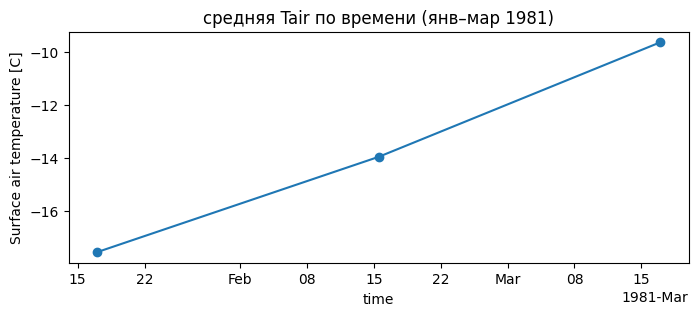

In [ ]:
spatial_mean = t_slice.mean(dim=['y','x'])

# Преобразуем координату времени в datetime64
spatial_mean['time'] = spatial_mean.indexes['time'].to_datetimeindex()

plt.figure(figsize=(8,3))
spatial_mean.plot(marker='o')
plt.title('средняя Tair по времени (янв–мар 1981)')
plt.show()


---

### **Задание 3. Выполнение арифметических операций**

1. Вычислите среднее значение данных `Tair` по измерению `time`.


In [ ]:
# Среднее ПО ВРЕМЕНИ (в каждой точке y,x) → карта средней Tair
tair_time_mean = tair.mean(dim="time")  # (y, x)

# Аномалии = Tair(t) - среднее_по_времени(y,x)
tair_anom = tair - tair_time_mean  # (time, y, x)

print("tair_anom создан Форма", tair_anom.shape)
print("Пример значения (первая дата, центр):",
      float(tair_anom.isel(time=0, y=100, x=130).values))

tair_anom создан Форма (36, 205, 275)
Пример значения (первая дата, центр): nan


2. Вычтите вычисленное среднее из исходного набора данных `Tair`, чтобы получить аномалии температуры.


In [ ]:
anom_spatial_mean = tair_anom.mean(dim=["y", "x"])
anom_spatial_mean["time"] = anom_spatial_mean.indexes["time"].to_datetimeindex()

/tmp/ipython-input-3223699249.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  anom_spatial_mean["time"] = anom_spatial_mean.indexes["time"].to_datetimeindex()
/tmp/ipython-input-3223699249.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  anom_spatial_mean["time"] = anom_spatial_mean.indexes["time"].to_datetimeindex()


3. Визуализируйте отдельно график средней температуры и график аномалий.

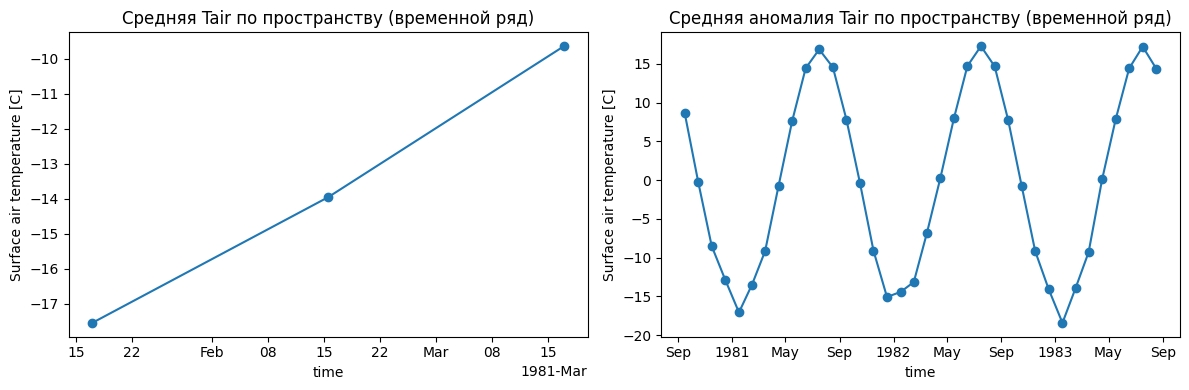

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
spatial_mean.plot(marker='o')
plt.title("Средняя Tair по пространству (временной ряд)")

plt.subplot(1,2,2)
anom_spatial_mean.plot(marker='o')
plt.title("Средняя аномалия Tair по пространству (временной ряд)")
plt.tight_layout()

plt.show()

---

### **Задание 4. GroupBy и агрегация**

1. Используйте `groupby` для расчета среднесезонной температуры (`Tair`).


In [ ]:
seasonal_mean = tair.groupby('time.season').mean(dim='time')
print('\nСреднесезонное значение (размерности):', seasonal_mean.sizes)

# среднемесячная температура за 1980 год (resample)
monthly_1980 = tair.sel(time=slice('1980-01-01','1980-12-31')).resample(time='1M').mean()
print('\nСреднемесячные значения за 1980 (количество месяцев):', monthly_1980.sizes['time'])


Среднесезонное значение (размерности): Frozen({'season': 4, 'y': 205, 'x': 275})

Среднемесячные значения за 1980 (количество месяцев): 4


<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


2. Используйте `resample` для расчета среднемесячной температуры за 1980 год.


In [ ]:
seasonal_mean_each = tair.groupby('time.season').mean('time')
monthly_mean_overall = tair.resample(time='1M').mean().mean(dim=['y','x'])

<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


3. Постройте сезонное среднее для каждого сезона и выведите среднемесячное значение.

In [ ]:
print('\nПример среднемесячного значения (усреднённое по пространству):')
print(monthly_mean_overall)


Пример среднемесячного значения (усреднённое по пространству):
<xarray.DataArray 'Tair' (time: 36)> Size: 288B
8.187 -0.7013 -8.989 -13.33 -17.54 -13.95 ... -0.376 7.35 13.93 16.75 13.86
Coordinates:
  * time     (time) object 288B 1980-09-30 00:00:00 ... 1983-08-31 00:00:00
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous


---

### **Задание 5. Запись данных в netCDF**

1. Выберите аномалии температуры, рассчитанные в Упражнении 3.


In [ ]:
# уже рассчитали

2. Преобразуйте переменную `Tair` в `float32` для оптимизации размера файла.


In [ ]:
tair_anom_f32 = tair_anom.astype('float32')

3. Запишите данные аномалий в новый файл netCDF с именем `tair_anomalies.nc`.


In [ ]:
out_fn = 'tair_anomalies.nc'
tair_anom_f32.to_netcdf(out_fn)
print(f"Сохранено в: {out_fn}")

Сохранено в: tair_anomalies.nc


4. Загрузите данные обратно из файла и выведите его содержимое.

In [ ]:
ds_reloaded = xr.open_dataset(out_fn)
print('\nЗагруженный файл — переменные:', list(ds_reloaded.data_vars))


Загруженный файл — переменные: ['Tair']


---

## **Раздел 2. Эффективная работа с наборами векторных данных в библиотеке RIOXARRAY**

### **Используемый набор данных для выполнения заданий**

Для выполнения заданий мы будем использовать образец растрового набора данных GeoTIFF Ливии, который доступен по следующему URL:


- https://github.com/opengeos/datasets/releases/download/raster/Libya-2023-09-13_clip.tif

---

### **Задание 1. Загрузка и исследование растрового набора данных**

1. Используйте `rioxarray` для загрузки файла GeoTIFF.


In [ ]:
libya_tif_url = 'https://github.com/opengeos/datasets/releases/download/raster/Libya-2023-09-13_clip.tif'

2. Изучите набор данных, выведя его размеры, координаты и атрибуты.


In [ ]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.7 MB/s eta 0:00:00


In [ ]:
import rioxarray as rxr

In [ ]:
raster = rxr.open_rasterio(libya_tif_url) # если среда поддерживает прямой доступ по URL

import requests
r = requests.get(libya_tif_url)
open('Libya-clip.tif','wb').write(r.content)
raster = rxr.open_rasterio('Libya-clip.tif')


print('Размеры:', raster.sizes)
print('Координаты:', raster.coords)
print('Атрибуты:', raster.attrs)

Размеры: Frozen({'band': 4, 'y': 1722, 'x': 2807})
Координаты: Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 14kB 3.628e+06 3.628e+06 ... 3.626e+06 3.626e+06
  * x            (x) float64 22kB 6.522e+05 6.522e+05 ... 6.55e+05 6.55e+05
    spatial_ref  int64 8B 0
Атрибуты: {'OVR_RESAMPLING_ALG': 'NEAREST', 'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0}


3. Проверьте и выведите CRS и аффинное преобразование набора данных.

In [ ]:
print('CRS:', raster.rio.crs)
print('Аффиное преобразование:\n', raster.rio.transform())

CRS: EPSG:32634
Аффиное преобразование:
 | 1.00, 0.00, 652207.03|
| 0.00,-1.00, 3627663.88|
| 0.00, 0.00, 1.00|


---

### **Задание 2. Перепроецирование растра в новую CRS**

1. Перепроецируйте загруженный растровый набор данных из его исходной CRS в EPSG:4326 (WGS84).


In [ ]:
raster_4326 = raster.rio.reproject('EPSG:4326')

2. Выведите новую CRS и проверьте размеры и координаты перепроецированных данных.


In [ ]:
print('Новая CRS:', raster_4326.rio.crs)
print('Новые размеры:', raster_4326.sizes)

Новая CRS: EPSG:4326
Новые размеры: Frozen({'band': 4, 'y': 1557, 'x': 2957})


3. Отобразите исходный и перепроецированный наборы данных для сравнения.

(array([ 735969.,  863741., 1625062., 2262505., 2071264., 1608684.,
        1436375., 1146708.,  966661., 5699227.]),
 array([  0. ,  25.5, ..., 229.5, 255. ]),
 <BarContainer object of 10 artists>)

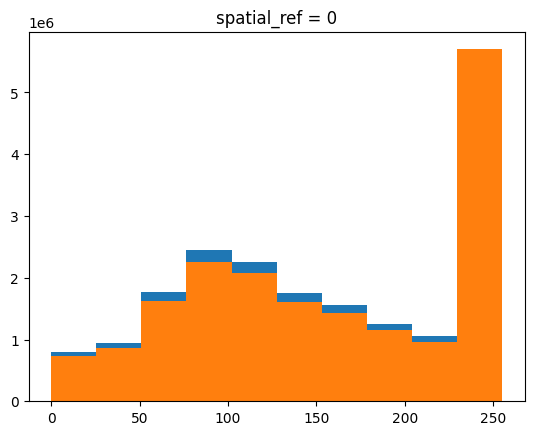

In [ ]:
raster.plot()
raster_4326.plot()

---

### **Задание 3. Обрезка растра с использованием ограничивающего прямоугольника**

1. Определите ограничивающий прямоугольник (например, `xmin`, `ymin`, `xmax`, `ymax`), который охватывает территорию Ливии.


In [ ]:
libya_bbox = {
'xmin': 9.5,
'ymin': 19.5,
'xmax': 25.5,
'ymax': 33.5
}

2. Обрежьте растровый набор данных, используя этот ограничивающий прямоугольник.


In [ ]:
raster_cropped = raster_4326.rio.clip_box(minx=libya_bbox['xmin'], miny=libya_bbox['ymin'], maxx=libya_bbox['xmax'], maxy=libya_bbox['ymax'])

3. Отобразите обрезанные данные для визуализации результата.

(array([ 735969.,  863741., 1625062., 2262505., 2071264., 1608684.,
        1436375., 1146708.,  966661., 5699227.]),
 array([  0. ,  25.5, ..., 229.5, 255. ]),
 <BarContainer object of 10 artists>)

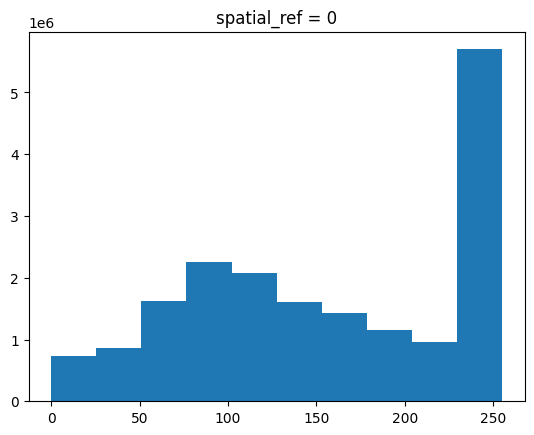

In [ ]:
raster_cropped.plot()

---

### **Задание 4. Маскирование растра с использованием векторного набора данных**

1. Загрузите файл GeoJSON по адресу https://github.com/opengeos/datasets/releases/download/raster/Derna_Libya.geojson, используя `geopandas`.


In [ ]:
geojson_url = 'https://github.com/opengeos/datasets/releases/download/raster/Derna_Libya.geojson'

2. Используйте GeoJSON для маскирования растрового набора данных, сохраняя только данные в пределах границ GeoJSON.


In [ ]:
import geopandas as gpd

In [ ]:
gdf = gpd.read_file(geojson_url)

3. Отобразите маскированные растровые данные.

/usr/local/lib/python3.12/dist-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


(array([124661.,  64541., 100829., 177657., 199678., 156565., 146944.,
        114559.,  89542., 437384.]),
 array([  0. ,  25.5, ..., 229.5, 255. ]),
 <BarContainer object of 10 artists>)

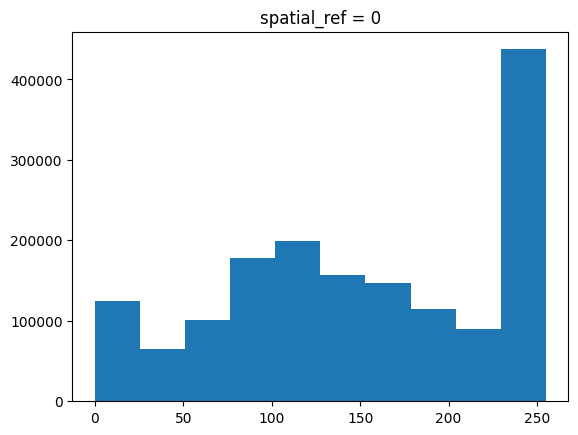

In [ ]:
if gdf.crs != raster.rio.crs:
  gdf = gdf.to_crs(raster.rio.crs)
raster_masked = raster.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)
raster_masked.plot()

---

### **Задание 5. Преобразование растра**

1. Выполните ресемплинг растрового набора данных до разрешения 3 м, используя метод усреднения.


In [ ]:
from rasterio.enums import Resampling

In [ ]:
raster_m = raster.rio.reproject('EPSG:3857')

raster_resampled = raster_m.rio.reproject(
  raster_m.rio.crs,
  resolution=(3, 3),
  resampling=Resampling.average
)

2. Проверьте новые размеры и координаты после ресемплинга.


In [ ]:
raster_resampled.rio.to_raster('libya_resampled_3m.tif')

3. Сохраните ресемплированный растровый набор данных в новый файл GeoTIFF.

In [ ]:
# уже сделали выше